Most sections use the **first recording in Part 1 (index 0)**. Section 8 compares the first five recordings. These are recording segments, not confirmed separate people. The results do not describe the whole dataset.

**The goal:** understand the signals, turn PPG pulses into measurements, and see how those measurements can be paired with blood-pressure targets. There is no trained model here yet.

Open this notebook from the BTT folder and use the project's `.venv` kernel. The saved graphs and tables can be read without rerunning. To reproduce them, choose **Run All**; `data/Part_1.mat` must be available locally. Outputs go to `reports/combined_eda`.


In [1]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from IPython.display import display
ROOT = Path.cwd()
DATA_FILE = ROOT / 'data' / 'Part_1.mat'
OUTPUT = ROOT / 'reports' / 'combined_eda'
OUTPUT.mkdir(parents=True, exist_ok=True)
RECORD_ID = 0
FS = 125
WINDOW = 5 * FS
if not DATA_FILE.exists():
    raise FileNotFoundError('Open this notebook from BTT with data/Part_1.mat available.')

## 1. Load one recording
A sample is one measurement. At 125 samples per second, five seconds contains 625 samples—not 625 pulses. We read the three channels, then use PPG for pulse features and ABP for pressure targets.

In [2]:
# 1. Load one recording. Each channel uses the same time axis.
with h5py.File(DATA_FILE, "r") as f:
    references = f[DATA_FILE.stem]
    reference = references[np.unravel_index(RECORD_ID, references.shape)]
    record = np.asarray(f[reference])
if record.ndim != 2:
    raise ValueError(f"Expected a two-dimensional recording, got {record.shape}")
if record.shape[0] != 3:
    record = record.T
if record.shape[0] != 3:
    raise ValueError(f"Expected three signal channels, got {record.shape}")

ppg, abp, ecg = record
signals = pd.DataFrame({"PPG": ppg, "ABP": abp, "ECG": ecg})
print(f"Part 1, recording index {RECORD_ID}")
print(f"{len(ppg):,} samples per channel; {len(ppg)/FS:.1f} seconds")
print(f"NeuroKit2 version: {nk.__version__}")

Part 1, recording index 0
61,000 samples per channel; 488.0 seconds
NeuroKit2 version: 0.2.10


## 2. Check the numbers before processing
Count NaNs, infinities and zeros separately, then look at basic statistics and histograms. Zeros are not automatically missing readings, so they are kept. Histograms show which values are common but lose time order. These counts cover this one recording only.


Signal checks (this recording only):


,missing_nan,infinite,zeros
PPG,0,0,15
ABP,0,0,0
ECG,0,0,0



Signal summary (ABP is in mmHg; PPG/ECG use stored units):


,PPG,ABP,ECG
count,61000.000,61000.000,61000.000
mean,1.840,94.658,0.226
std,0.632,20.567,0.255
min,0.000,50.163,-0.240
25%,1.310,78.541,0.090
50%,1.624,86.259,0.185
75%,2.422,112.928,0.305
max,4.002,160.111,1.501


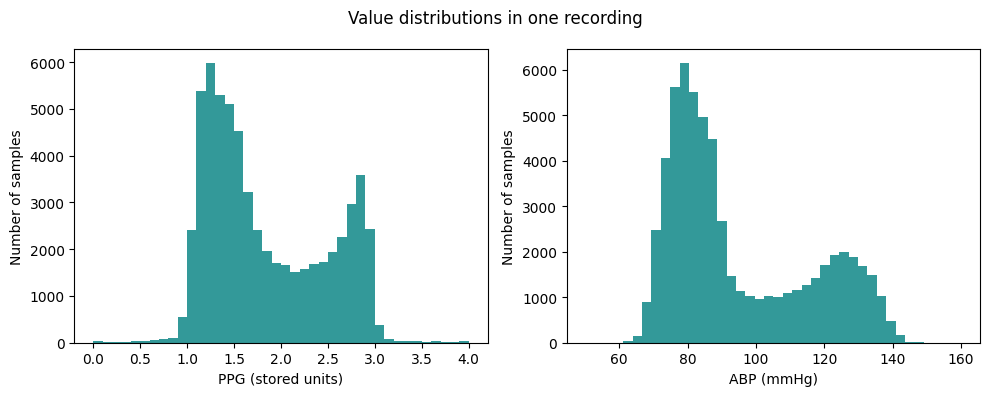

In [3]:
# 2. Basic EDA: check missing readings and describe the stored values.
# A zero is counted separately. It is not automatically a missing value.
checks = pd.DataFrame({
    "missing_nan": signals.isna().sum(),
    "infinite": np.isinf(signals).sum(),
    "zeros": signals.eq(0).sum(),
})
print("\nSignal checks (this recording only):")
display(checks)
print("\nSignal summary (ABP is in mmHg; PPG/ECG use stored units):")
display(signals.describe().round(3))
checks.to_csv(OUTPUT / "signal_checks.csv")
signals.describe().to_csv(OUTPUT / "signal_summary.csv")
if not np.isfinite(record[:2]).all():
    raise ValueError("PPG or ABP contains nonfinite values. Review before processing.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, label in zip(axes, [ppg, abp], ["PPG (stored units)", "ABP (mmHg)"]):
    ax.hist(values, bins=40, color="teal", alpha=0.8)
    ax.set(xlabel=label, ylabel="Number of samples")
fig.suptitle("Value distributions in one recording")
fig.tight_layout()
fig.savefig(OUTPUT / "value_distributions.png", dpi=150)
plt.show()

## 3. Use NeuroKit2 to find PPG pulses
First filter the PPG with `ppg_clean`, then detect candidate peaks with `ppg_peaks`. These are explicit steps from the NeuroKit2 PPG workflow. We process the whole recording so each window has surrounding context. This is offline processing; filtering does not guarantee a correct waveform.

In [4]:
# 3. Filter PPG and find pulse peaks with NeuroKit2.
# Using the full recording gives the filter context around each window.
# This is offline processing, not a live sensor pipeline.
cleaned = nk.ppg_clean(ppg, sampling_rate=FS, method="elgendi")
_, info = nk.ppg_peaks(cleaned, sampling_rate=FS, method="elgendi")
ppg_peaks = np.asarray(info["PPG_Peaks"], dtype=int)

## 4. Find candidate pressure highs and lows
ABP has pressure units: mmHg. SciPy finds candidate peaks with a minimum spacing of 0.30 seconds and prominence of 10 mmHg. Prominence describes how far a peak stands above nearby lows. The minimum between successive peaks is a candidate trough. These settings are a starting point that needs review, not a validated labeling method.

In [5]:
# 4. Find candidate high/low ABP points for draft pressure targets.
# These detector settings need checking on more recordings.
pressure_peaks, _ = find_peaks(abp, distance=round(0.30 * FS), prominence=10)
left, right = pressure_peaks[:-1], pressure_peaks[1:]
troughs = np.array([
    a + np.argmin(abp[a:b + 1]) for a, b in zip(left, right)
], dtype=int)

## 5. Make a table for five-second windows
Each row describes one window. Pulse rate is 60 divided by the median gap between PPG peaks in seconds. Draft SBP and DBP are median high and low ABP values from complete peak-to-peak intervals inside the window. We use the left peak and the following trough for each interval. Boundary intervals are omitted. If there are no intervals, the draft targets stay missing. PPG columns are possible inputs; ABP columns are target information, not PPG-only model inputs.

In [6]:
# 5. Make one row per complete five-second window.
# Pulse rate = 60 / median gap between PPG peaks (in seconds).
# Draft SBP/DBP = median high/low ABP values from complete peak-to-peak
# intervals inside the window. Boundary intervals are left out.
rows = []
for wid in range(len(ppg) // WINDOW):
    a, b = wid * WINDOW, (wid + 1) * WINDOW
    selected = ppg_peaks[(ppg_peaks >= a) & (ppg_peaks < b)]
    gaps = np.diff(selected) / FS
    median_gap = float(np.median(gaps)) if len(gaps) else np.nan
    complete = (left >= a) & (right < b)
    rows.append({
        "source_file": DATA_FILE.name,
        "record_id": RECORD_ID,
        "window_id": wid,
        "start_seconds": a / FS,
        "ppg_pulse_count": len(selected),
        "ppg_median_gap_seconds": median_gap,
        "ppg_pulse_rate_bpm": 60 / median_gap if median_gap > 0 else np.nan,
        "ppg_cleaned_std": float(np.std(cleaned[a:b])),
        "abp_complete_intervals": int(complete.sum()),
        "draft_sbp_mmHg": float(np.median(abp[left[complete]])) if complete.any() else np.nan,
        "draft_dbp_mmHg": float(np.median(abp[troughs[complete]])) if complete.any() else np.nan,
        "target_status": "draft_unvalidated" if complete.any() else "missing_no_intervals",
    })
windows = pd.DataFrame(rows)
windows.to_csv(OUTPUT / "window_features_and_draft_targets.csv", index=False)
print(f"\nCreated {len(windows)} windows; {len(ppg) % WINDOW} trailing samples left out.")
print("Example windows:")
display(windows.iloc[1:4].round(3))


Created 97 windows; 375 trailing samples left out.
Example windows:


,source_file,record_id,window_id,start_seconds,ppg_pulse_count,ppg_median_gap_seconds,ppg_pulse_rate_bpm,ppg_cleaned_std,abp_complete_intervals,draft_sbp_mmHg,draft_dbp_mmHg,target_status
1,Part_1.mat,0,1,5.0,10,0.480,125.000,0.610,9,124.357,68.821,draft_unvalidated
2,Part_1.mat,0,2,10.0,11,0.488,122.951,0.623,9,125.871,69.798,draft_unvalidated
3,Part_1.mat,0,3,15.0,10,0.488,122.951,0.609,9,122.989,67.551,draft_unvalidated


## 6. Check the markers against the waveform
Look at the same 5–10 seconds in all three plots. The original and filtered PPG have separate scales. Orange dots should follow the main PPG pulses. On ABP, the marked highs and lows are the ones contributing to the draft targets. The final ABP peak may be unmarked because its following interval is outside the window.

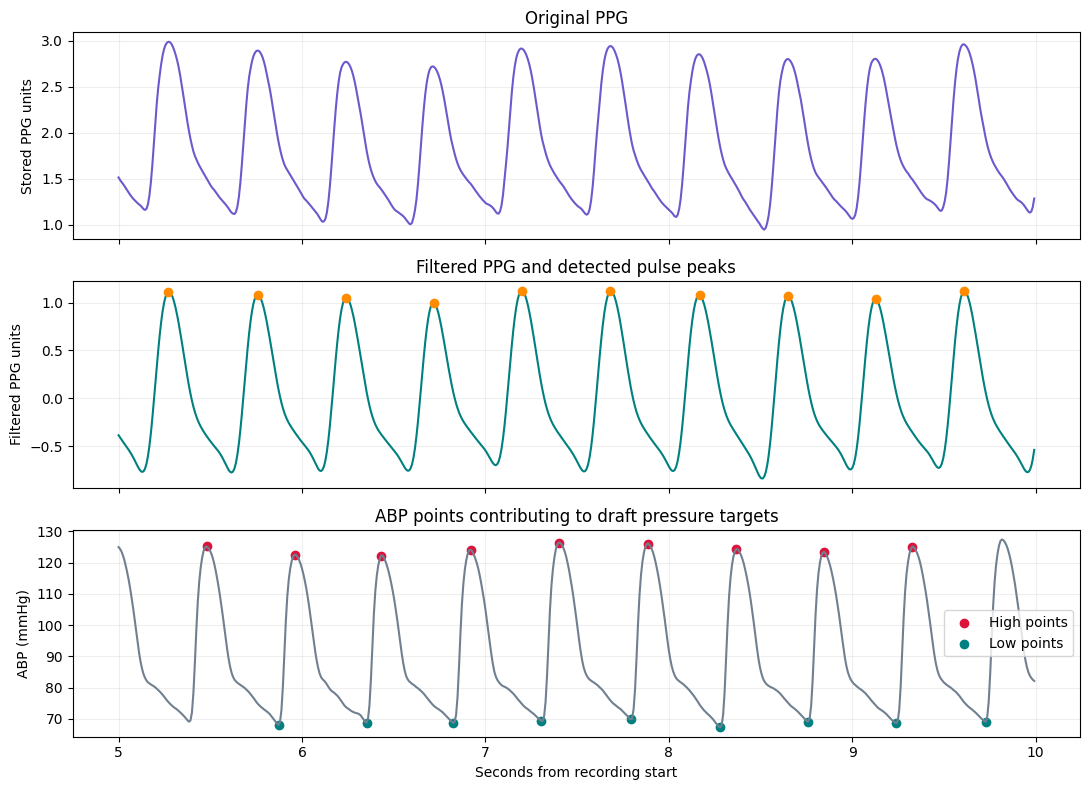

In [7]:
# 6. Look at 5–10 seconds to check the detected peaks against the signals.
a, b = WINDOW, 2 * WINDOW
if b <= len(ppg):
    time = np.arange(a, b) / FS
    selected = ppg_peaks[(ppg_peaks >= a) & (ppg_peaks < b)]
    complete = (left >= a) & (right < b)
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    axes[0].plot(time, ppg[a:b], color="slateblue")
    axes[0].set(ylabel="Stored PPG units", title="Original PPG")
    axes[1].plot(time, cleaned[a:b], color="teal")
    axes[1].scatter(selected / FS, cleaned[selected], color="darkorange", zorder=3)
    axes[1].set(ylabel="Filtered PPG units", title="Filtered PPG and detected pulse peaks")
    axes[2].plot(time, abp[a:b], color="slategray")
    axes[2].scatter(left[complete] / FS, abp[left[complete]], color="crimson", label="High points")
    axes[2].scatter(troughs[complete] / FS, abp[troughs[complete]], color="teal", label="Low points")
    axes[2].set(xlabel="Seconds from recording start", ylabel="ABP (mmHg)",
                title="ABP points contributing to draft pressure targets")
    axes[2].legend()
    for ax in axes:
        ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(OUTPUT / "ppg_and_abp_peaks.png", dpi=150)
    plt.show()

## 7. See what changes over time
Each point now represents a five-second window. Look for gradual changes and sudden jumps. A jump can reflect real variation or detection problems; the plot alone does not distinguish them. The pressure lines are derived from ABP, not model predictions.

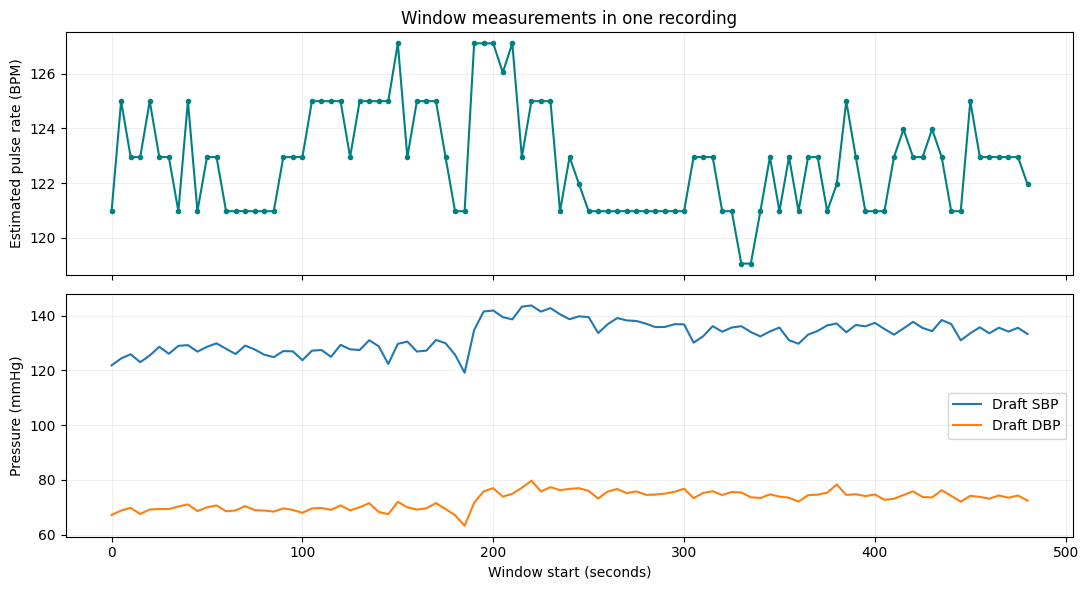

In [8]:
# 7. See how the measurements change from window to window.
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(windows.start_seconds, windows.ppg_pulse_rate_bpm, ".-", color="teal")
axes[0].set(ylabel="Estimated pulse rate (BPM)", title="Window measurements in one recording")
axes[1].plot(windows.start_seconds, windows.draft_sbp_mmHg, label="Draft SBP")
axes[1].plot(windows.start_seconds, windows.draft_dbp_mmHg, label="Draft DBP")
axes[1].set(xlabel="Window start (seconds)", ylabel="Pressure (mmHg)")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "measurements_by_window.png", dpi=150)
plt.show()

## 8. Compare the first five recordings
Do the other recordings look similar in length and pulse timing? Each box summarizes window pulse rates from one recording. Its line is the median, the box contains the middle half, and individual points beyond the whiskers are unusual values—not automatic errors. Different recording lengths mean different numbers of candidate training windows. Mean ABP is not SBP or DBP.


First five recordings (mean ABP is not SBP or DBP):


,record_id,duration_seconds,complete_windows,windows_without_rate,median_window_pulse_rate_bpm,ppg_mean,ppg_std,mean_abp_mmHg
0,0,488.0,97,0,122.95,1.84,0.63,94.66
1,1,488.0,97,0,119.05,1.83,0.63,91.75
2,2,400.0,80,0,115.38,1.83,0.63,98.13
3,3,560.0,112,0,117.19,1.83,0.61,93.37
4,4,552.0,110,0,108.70,1.77,0.63,92.79


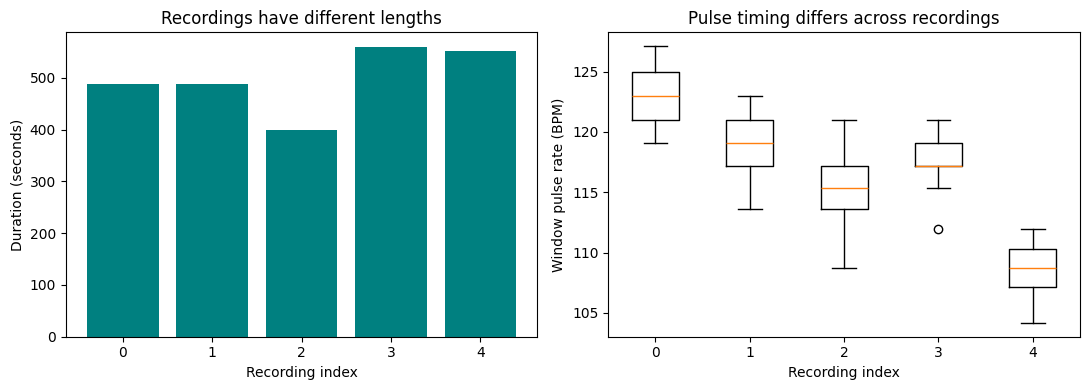

In [9]:
# 8. Compare the first five recordings instead of relying on one example.
# These are recording segments, not five confirmed different people.
comparison_rows = []
rate_groups = []
with h5py.File(DATA_FILE, "r") as f:
    references = f[DATA_FILE.stem]
    for rid in range(min(5, references.size)):
        x = np.asarray(f[references[np.unravel_index(rid, references.shape)]])
        if x.shape[0] != 3:
            x = x.T
        if not np.isfinite(x[:2]).all():
            raise ValueError(f"Review nonfinite readings in recording {rid}.")
        filtered = nk.ppg_clean(x[0], sampling_rate=FS, method="elgendi")
        _, detected = nk.ppg_peaks(filtered, sampling_rate=FS, method="elgendi")
        pk = np.asarray(detected["PPG_Peaks"], dtype=int)
        rates = []
        for wid in range(x.shape[1] // WINDOW):
            in_window = pk[(pk >= wid*WINDOW) & (pk < (wid+1)*WINDOW)]
            gaps = np.diff(in_window) / FS
            rates.append(60 / np.median(gaps) if len(gaps) else np.nan)
        rates = np.asarray(rates)
        finite_rates = rates[np.isfinite(rates)]
        rate_groups.append(finite_rates)
        comparison_rows.append({
            "record_id": rid,
            "duration_seconds": x.shape[1] / FS,
            "complete_windows": len(rates),
            "windows_without_rate": int(np.isnan(rates).sum()),
            "median_window_pulse_rate_bpm": float(np.median(finite_rates)) if len(finite_rates) else np.nan,
            "ppg_mean": float(x[0].mean()),
            "ppg_std": float(x[0].std()),
            "mean_abp_mmHg": float(x[1].mean()),
        })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUTPUT / "first_five_recordings.csv", index=False)
print("\nFirst five recordings (mean ABP is not SBP or DBP):")
display(comparison.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparison.record_id.astype(str), comparison.duration_seconds, color="teal")
axes[0].set(xlabel="Recording index", ylabel="Duration (seconds)", title="Recordings have different lengths")
axes[1].boxplot(rate_groups, tick_labels=comparison.record_id.astype(str).tolist())
axes[1].set(xlabel="Recording index", ylabel="Window pulse rate (BPM)", title="Pulse timing differs across recordings")
fig.tight_layout()
fig.savefig(OUTPUT / "first_five_recordings.png", dpi=150)
plt.show()

**What came out:** the first five recordings range from 400 to 560 seconds. Their median window pulse rates range from about 109 to 123 BPM. A result from recording 0 does not describe every recording.

## 9. Try three pressure-detector settings
Keep the minimum spacing fixed and change peak prominence to 5, 10 and 15 mmHg. Compare only windows with available targets at all three settings. This checks whether one choice changes our results. Agreement does not prove the peaks are correct, especially in just one recording.

In [10]:
# 9. Check whether the ABP detector setting changes our draft targets.
# Prominence measures how much a peak stands above nearby low points.
# Agreement across settings is reassuring, but does not prove correctness.
sensitivity_rows = []
for prominence in [5, 10, 15]:
    bp, _ = find_peaks(abp, distance=round(.30*FS), prominence=prominence)
    lows = np.array([a + np.argmin(abp[a:b+1]) for a, b in zip(bp[:-1], bp[1:])], dtype=int)
    for wid in range(len(abp) // WINDOW):
        valid = (bp[:-1] >= wid*WINDOW) & (bp[1:] < (wid+1)*WINDOW)
        sensitivity_rows.append({
            "window_id": wid, "prominence_mmHg": prominence,
            "complete_intervals": int(valid.sum()),
            "draft_sbp_mmHg": float(np.median(abp[bp[:-1][valid]])) if valid.any() else np.nan,
            "draft_dbp_mmHg": float(np.median(abp[lows[valid]])) if valid.any() else np.nan,
        })
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(OUTPUT / "pressure_detector_comparison.csv", index=False)
print("\nTarget differences across three detector settings (recording 0 only):")
for target in ["draft_sbp_mmHg", "draft_dbp_mmHg"]:
    table = sensitivity.pivot(index="window_id", columns="prominence_mmHg", values=target)
    comparable = table.dropna()  # Compare only windows with targets at every setting.
    spread = comparable.max(axis=1) - comparable.min(axis=1)
    print(f"{target}: {len(comparable)} comparable windows; "
          f"{int((spread > 0.01).sum())} differ by more than 0.01 mmHg; "
          f"largest difference = {spread.max():.2f} mmHg")


Target differences across three detector settings (recording 0 only):
draft_sbp_mmHg: 97 comparable windows; 0 differ by more than 0.01 mmHg; largest difference = 0.00 mmHg
draft_dbp_mmHg: 97 comparable windows; 0 differ by more than 0.01 mmHg; largest difference = 0.00 mmHg


**What came out:** all 97 windows have targets at each of the three settings. Neither draft SBP nor DBP changes here. This particular prominence check is stable; other detector choices and other recordings still need checking.

## 10. Compare beat summaries with single extremes
A window maximum/minimum uses just one sample. Our draft targets use medians across detected intervals. Plot the differences to see how much this choice matters. A large difference is a reason to inspect the waveform; it is not proof that one method is right.


Largest gaps between draft DBP and the raw window minimum:


,window_id,draft_sbp_mmHg,draft_dbp_mmHg,raw_max_mmHg,raw_min_mmHg,max_minus_draft_sbp,draft_dbp_minus_min
46,46,142.75,77.37,160.11,55.73,17.36,21.64
37,37,119.13,63.28,122.11,50.16,2.98,13.11
38,38,134.76,71.65,138.81,62.81,4.05,8.84


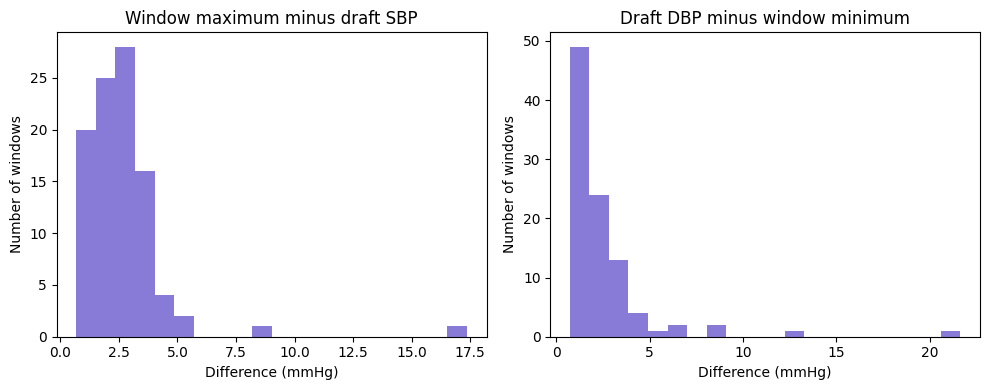

In [11]:
# 10. Compare beat medians with the single highest/lowest sample.
# One unusual sample can affect an extreme more than a median.
complete_abp = abp[:len(windows)*WINDOW].reshape(-1, WINDOW)
target_check = windows[["window_id", "draft_sbp_mmHg", "draft_dbp_mmHg"]].copy()
target_check["raw_max_mmHg"] = complete_abp.max(axis=1)
target_check["raw_min_mmHg"] = complete_abp.min(axis=1)
target_check["max_minus_draft_sbp"] = target_check.raw_max_mmHg - target_check.draft_sbp_mmHg
target_check["draft_dbp_minus_min"] = target_check.draft_dbp_mmHg - target_check.raw_min_mmHg
target_check.to_csv(OUTPUT / "pressure_summary_comparison.csv", index=False)
print("\nLargest gaps between draft DBP and the raw window minimum:")
display(target_check.nlargest(3, "draft_dbp_minus_min").round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, difference, title in zip(axes,
        [target_check.max_minus_draft_sbp, target_check.draft_dbp_minus_min],
        ["Window maximum minus draft SBP", "Draft DBP minus window minimum"]):
    ax.hist(difference.dropna(), bins=20, color="slateblue", alpha=.8)
    ax.set(xlabel="Difference (mmHg)", ylabel="Number of windows", title=title)
fig.tight_layout()
fig.savefig(OUTPUT / "pressure_summary_comparison.png", dpi=150)
plt.show()

## 11. Look at the window with the largest pressure-summary difference
Instead of stopping at a number, return to the original signal. Select the window where draft DBP is furthest above the raw minimum. The dashed line is the median of the contributing troughs; the cross marks the single lowest reading.

This is a deliberately selected extreme example, not a typical window. Look for whether the low reading is isolated, whether neighboring beats also change, and whether the detector markers still make sense.

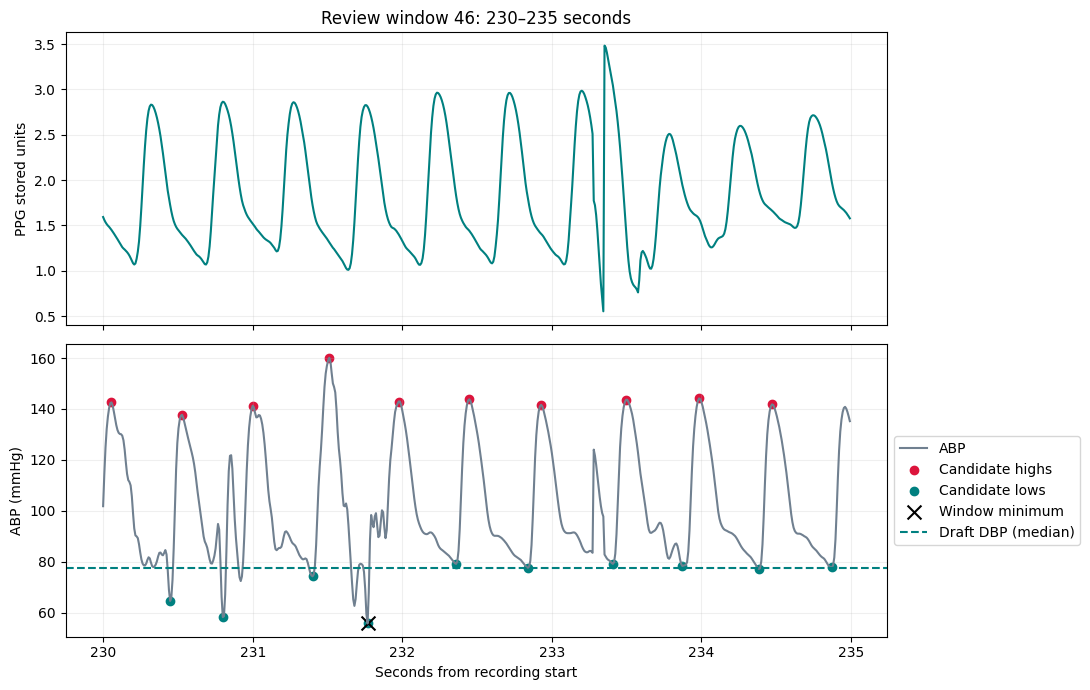

,window_id,draft_sbp_mmHg,draft_dbp_mmHg,raw_max_mmHg,raw_min_mmHg,max_minus_draft_sbp,draft_dbp_minus_min
46,46,142.75,77.37,160.11,55.73,17.36,21.64


In [12]:
review_id = int(target_check.loc[target_check.draft_dbp_minus_min.idxmax(), 'window_id'])
a, b = review_id*WINDOW, (review_id+1)*WINDOW
inside = (left >= a) & (right < b)
review = windows.loc[windows.window_id.eq(review_id)].iloc[0]
minimum_index = a + int(np.argmin(abp[a:b]))
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t = np.arange(a,b)/FS
axes[0].plot(t, ppg[a:b], color='teal')
axes[0].set(ylabel='PPG stored units', title=f'Review window {review_id}: {a/FS:.0f}–{b/FS:.0f} seconds')
axes[1].plot(t, abp[a:b], color='slategray', label='ABP')
axes[1].scatter(left[inside]/FS, abp[left[inside]], color='crimson', label='Candidate highs')
axes[1].scatter(troughs[inside]/FS, abp[troughs[inside]], color='teal', label='Candidate lows')
axes[1].scatter(minimum_index/FS, abp[minimum_index], marker='x', s=100, color='black', label='Window minimum')
axes[1].axhline(review.draft_dbp_mmHg, linestyle='--', color='teal', label='Draft DBP (median)')
axes[1].set(xlabel='Seconds from recording start', ylabel='ABP (mmHg)')
axes[1].legend(loc='center left', bbox_to_anchor=(1,.5))
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(OUTPUT/'largest_target_difference.png', dpi=150); plt.show()
display(target_check.loc[target_check.window_id.eq(review_id)].round(2))

**What to notice:** window 46 has draft DBP of 77.37 mmHg but a raw minimum of 55.73 mmHg. The low sample occurs in a visibly irregular section of ABP. PPG also has an abrupt change later in this window. This window belongs on the review list; taking a median does not make all of its data reliable.

## 12. Do PPG measurements vary with draft pressure targets?
Plot pulse rate and filtered PPG variation against draft SBP and DBP. Each dot is one five-second window from recording 0. Color indicates time so we can see whether groups of points come from the same part of the recording.

An upward pattern would mean the two measurements tend to rise together in these windows. It does not establish that one causes the other, or that a model would predict pressure well in another recording. The targets are still draft values.

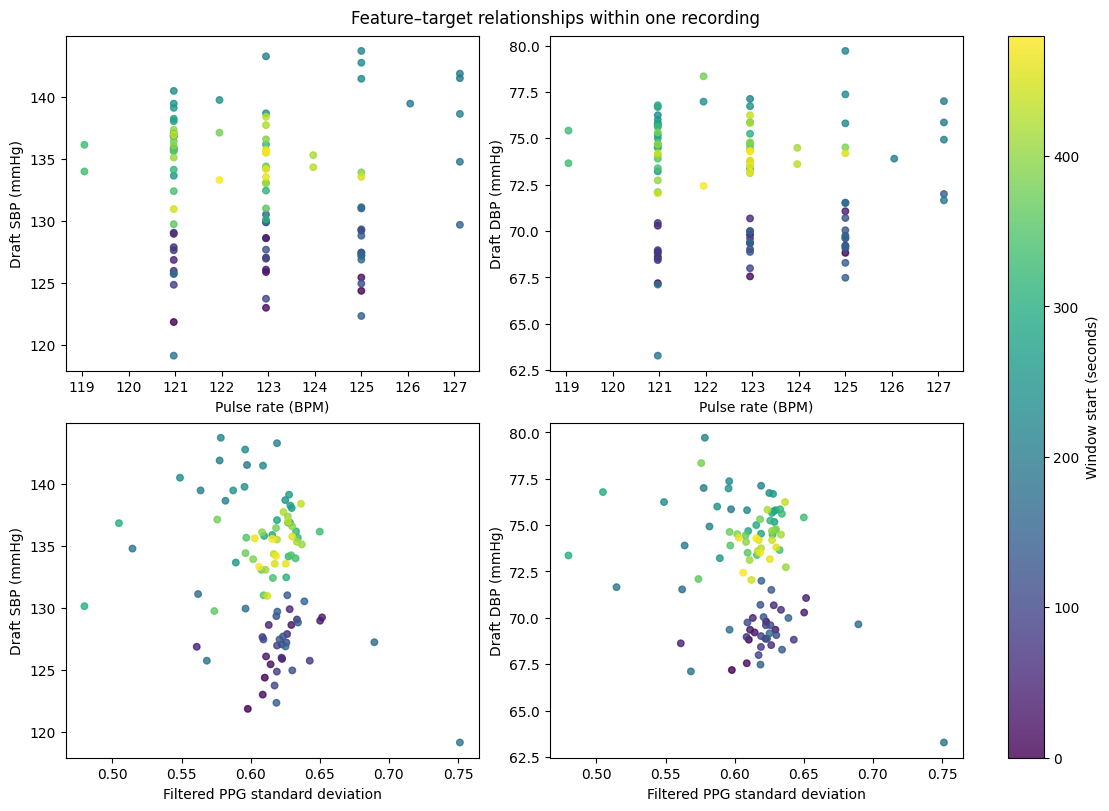

,draft_sbp_mmHg,draft_dbp_mmHg
ppg_pulse_rate_bpm,-0.074,-0.078
ppg_cleaned_std,-0.145,-0.117


In [13]:
input_features = ['ppg_pulse_rate_bpm', 'ppg_cleaned_std']
target_features = ['draft_sbp_mmHg', 'draft_dbp_mmHg']
fig, axes = plt.subplots(2,2,figsize=(11,8), layout='constrained')
for row, feature in enumerate(input_features):
    for col, target in enumerate(target_features):
        dots = axes[row,col].scatter(windows[feature], windows[target], c=windows.start_seconds,
                                     cmap='viridis', s=22, alpha=.8)
        axes[row,col].set(xlabel='Pulse rate (BPM)' if row==0 else 'Filtered PPG standard deviation',
                          ylabel='Draft SBP (mmHg)' if col==0 else 'Draft DBP (mmHg)')
fig.colorbar(dots, ax=axes.ravel().tolist(), label='Window start (seconds)')
fig.suptitle('Feature–target relationships within one recording')
fig.savefig(OUTPUT/'ppg_features_vs_draft_pressure.png', dpi=150); plt.show()
relationships = windows[input_features+target_features].corr(method='spearman').loc[input_features,target_features]
display(relationships.round(3))
relationships.to_csv(OUTPUT/'feature_target_spearman.csv')

the same pulse rate appears alongside several different pressure values. All four window-level Spearman correlations are weak here (roughly −0.07 to −0.14). These two features alone do not show a strong monotonic relationship with the draft targets in this record. The vertical bands in pulse rate also reflect sample-based peak timing and the median-gap calculation.

## 13. Does the relationship also appear in changes between windows?
Nearby windows share the same recording and may move together over time. Compare the relationship in their levels with the relationship in their **changes**: subtract the previous window's value from the current one.

For example, a pulse-rate change of +2 means the estimate increased by 2 BPM since the preceding window. We keep only truly adjacent windows, so a missing window cannot create a false consecutive pair. Spearman correlation summarizes whether larger values tend to go with larger values; it ranges from −1 to +1. A value near zero means little monotonic association, not proof of no possible relationship.

This is another descriptive view, not a statistical independence test or a model evaluation. Differencing does not remove every time-series dependency.

In [14]:
ordered = windows.sort_values('window_id').set_index('window_id')
values = ordered[input_features+target_features]
adjacent = ordered.index.to_series().diff().eq(1)
changes = values.diff().loc[adjacent]
change_correlations = changes.corr(method='spearman').loc[input_features,target_features]
comparison_rows = []
for feature in input_features:
    for target in target_features:
        comparison_rows.append({
            'PPG_feature':feature, 'draft_target':target,
            'window_level_correlation':relationships.loc[feature,target],
            'adjacent_change_correlation':change_correlations.loc[feature,target],
            'complete_window_pairs':len(values[[feature,target]].dropna()),
            'complete_change_pairs':len(changes[[feature,target]].dropna()),
        })
relationship_comparison = pd.DataFrame(comparison_rows)
display(relationship_comparison.round(3))
relationship_comparison.to_csv(OUTPUT/'levels_vs_changes.csv',index=False)
assert len(windows) == len(ppg)//WINDOW
assert windows[['source_file','record_id','window_id']].duplicated().sum() == 0
print('Finished. Tables and plots saved to', OUTPUT)

,PPG_feature,draft_target,window_level_correlation,adjacent_change_correlation,complete_window_pairs,complete_change_pairs
0,ppg_pulse_rate_bpm,draft_sbp_mmHg,-0.074,0.053,97,96
1,ppg_pulse_rate_bpm,draft_dbp_mmHg,-0.078,0.379,97,96
2,ppg_cleaned_std,draft_sbp_mmHg,-0.145,0.268,97,96
3,ppg_cleaned_std,draft_dbp_mmHg,-0.117,0.165,97,96


Finished. Tables and plots saved to /Users/charisxiong/Desktop/BTT/reports/combined_eda
